In [2]:
import polars as pl, pymc as pm, arviz as az

df = pl.read_csv("../../Rethinking_2/End_of_chapter_problems/data/tulips.csv", separator=";")

In [3]:
df = df.with_columns(
    blooms=pl.col("blooms")/pl.col("blooms").max(),
    water=pl.col("water")-pl.col("water").mean(),
    shade=pl.col("shade")-pl.col("shade").mean(),
    bed_idx=pl.col("bed").cast(pl.Categorical).to_physical()
)

In [4]:
# design coordinates for model
coords = {
    "bed": df["bed"].sort().unique().to_list()
}

In [5]:
with pm.Model() as basic_model:
    alpha = pm.Normal("alpha", mu=0, sigma=0.5)
    betas = pm.Normal("betas", mu=0, sigma=0.25, shape=2)

    mu = pm.Deterministic("mu", alpha + pm.math.dot(df.select("water", "shade").to_numpy(), betas))
    sigma = pm.Exponential("sigma", 5)

    blooms = pm.Normal("blooms", mu, sigma, observed=df["blooms"].to_numpy())

    # sample prior predictive
    basic_prior_predictive = pm.sample_prior_predictive()

    # fit the model
    basic_posterior = pm.sample()
    basic_posterior_predictive = pm.sample_posterior_predictive(basic_posterior)

    pm.compute_log_likelihood(basic_posterior)

with pm.Model() as interaction_model:
    alpha = pm.Normal("alpha", mu=0, sigma=0.5)
    betas = pm.Normal("betas", mu=0, sigma=0.25, shape=2)
    interaction_beta = pm.Normal("interaction_beta", mu=0, sigma=0.25)

    mu = pm.Deterministic("mu", (alpha +
                                 pm.math.dot(df.select("water", "shade").to_numpy(), betas) +
                                 interaction_beta*((df["shade"]*df["water"]).to_numpy()))
                          )
    sigma = pm.Exponential("sigma", 5)

    blooms = pm.Normal("blooms", mu, sigma, observed=df["blooms"].to_numpy())

    # sample prior predictive
    interaction_prior_predictive = pm.sample_prior_predictive()

    # fit the model
    interaction_posterior = pm.sample()
    interaction_posterior_predictive = pm.sample_posterior_predictive(interaction_posterior)

    pm.compute_log_likelihood(interaction_posterior)

with pm.Model(coords=coords) as interaction_bed_model:
    alphas = pm.Normal("alpha", mu=0, sigma=0.5, dims="bed")
    betas = pm.Normal("betas", mu=0, sigma=0.25, shape=2)
    interaction_beta = pm.Normal("interaction_beta", mu=0, sigma=0.25)

    mu = pm.Deterministic("mu", (alphas[pm.Data("bed_idx", df["bed_idx"].to_numpy())] +
                                 pm.math.dot(df.select("water", "shade").to_numpy(), betas) +
                                 interaction_beta*((df["shade"]*df["water"]).to_numpy()))
                          )
    sigma = pm.Exponential("sigma", 5)

    blooms = pm.Normal("blooms", mu, sigma, observed=df["blooms"].to_numpy())

    # sample prior predictive
    interaction_bed_prior_predictive = pm.sample_prior_predictive()

    # fit the model
    interaction_bed_posterior = pm.sample()
    interaction_bed_posterior_predictive = pm.sample_posterior_predictive(interaction_bed_posterior)

    pm.compute_log_likelihood(interaction_bed_posterior)

Sampling: [alpha, betas, blooms, sigma]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, betas, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
Sampling: [blooms]


Output()

Output()

...

Sampling: [alpha, betas, blooms, interaction_beta, sigma]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, betas, interaction_beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
Sampling: [blooms]


Output()

Output()

array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'betas'}>,
        <Axes: title={'center': 'betas'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>],
       [<Axes: title={'center': 'mu'}>, <Axes: title={'center': 'mu'}>]],
      dtype=object)

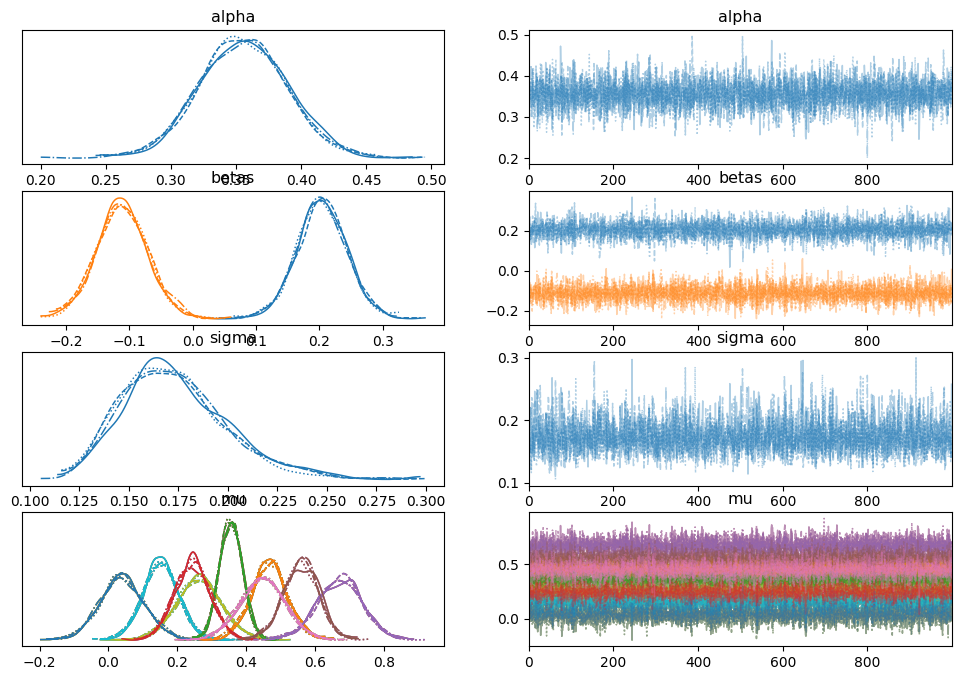

In [6]:
az.plot_trace(basic_posterior)

array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'betas'}>,
        <Axes: title={'center': 'betas'}>],
       [<Axes: title={'center': 'interaction_beta'}>,
        <Axes: title={'center': 'interaction_beta'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>],
       [<Axes: title={'center': 'mu'}>, <Axes: title={'center': 'mu'}>]],
      dtype=object)

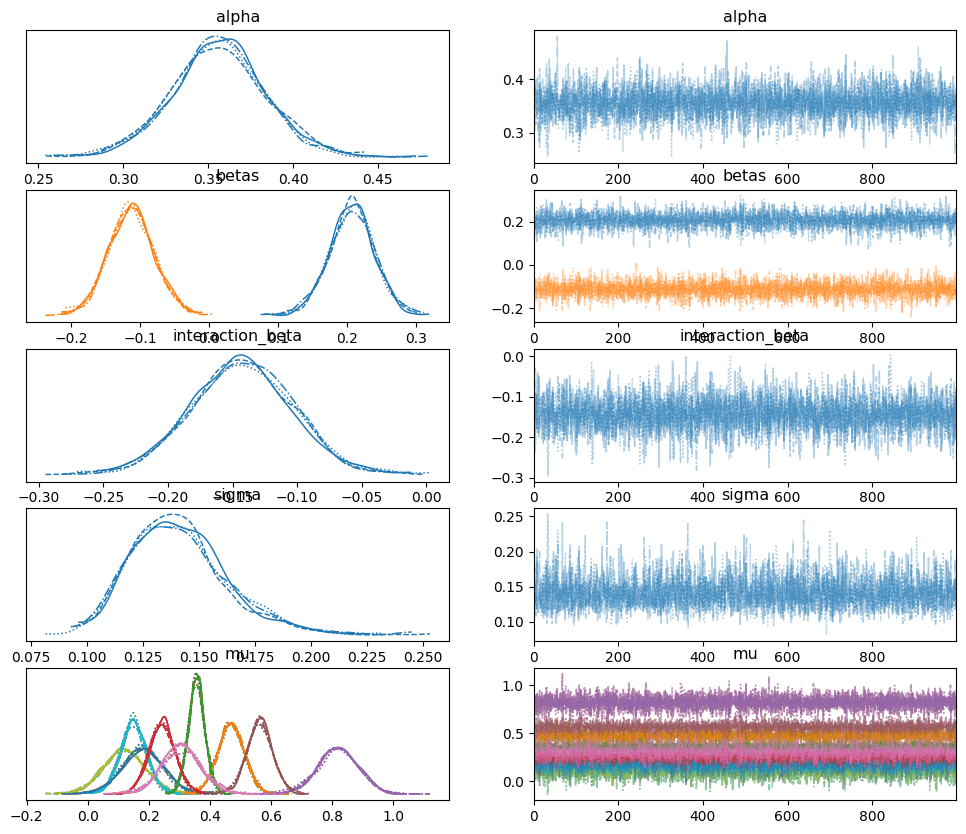

In [7]:
az.plot_trace(interaction_posterior)

array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'betas'}>,
        <Axes: title={'center': 'betas'}>],
       [<Axes: title={'center': 'interaction_beta'}>,
        <Axes: title={'center': 'interaction_beta'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>]], dtype=object)

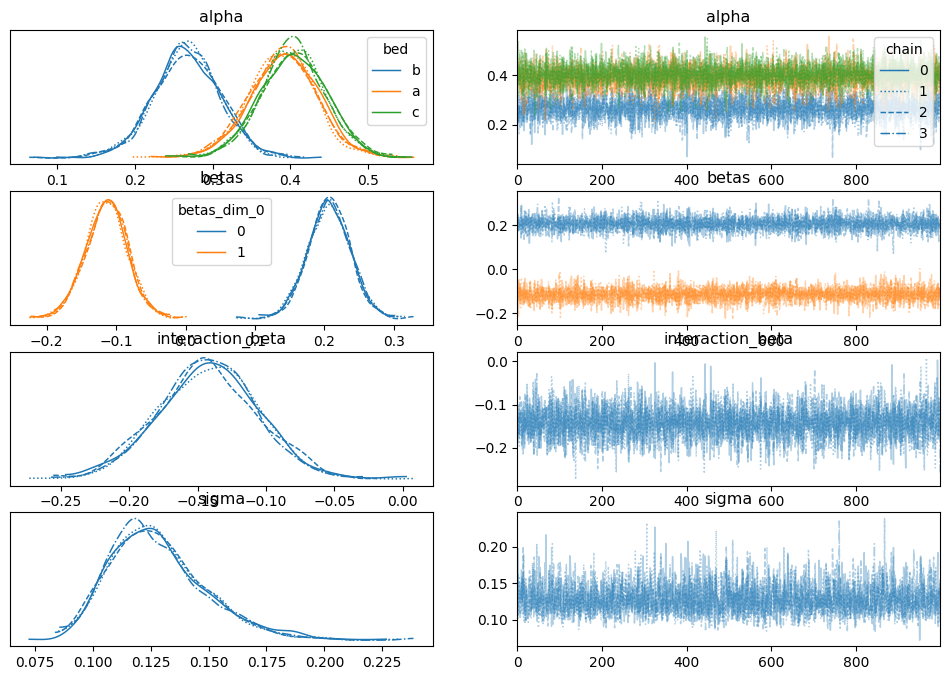

In [8]:
az.plot_trace(interaction_bed_posterior, coords=coords, legend=True, var_names=["~mu"])

In [9]:
az.summary(interaction_bed_posterior)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha[b],0.267,0.043,0.189,0.348,0.001,0.001,4341.0,2788.0,1.0
alpha[a],0.390,0.044,0.304,0.470,0.001,0.001,4504.0,2602.0,1.0
alpha[c],0.404,0.042,0.330,0.490,0.001,0.001,5541.0,2882.0,1.0
betas[0],0.207,0.031,0.148,0.264,0.000,0.001,5538.0,2573.0,1.0
betas[1],-0.114,0.031,-0.170,-0.054,0.000,0.001,5036.0,2964.0,1.0
interaction_beta,-0.142,0.037,-0.210,-0.073,0.001,0.001,4797.0,2942.0,1.0
sigma,0.128,0.021,0.092,0.167,0.000,0.000,2934.0,2509.0,1.0
mu[0],0.032,0.072,-0.104,0.167,0.001,0.001,4866.0,3121.0,1.0
mu[1],0.060,0.053,-0.040,0.158,0.001,0.001,4653.0,2371.0,1.0
mu[2],0.088,0.071,-0.046,0.223,0.001,0.001,4593.0,2755.0,1.0


In [10]:
comparison = az.compare({
    "basic": basic_posterior,
    "interaction": interaction_posterior,
    "interaction_bed": interaction_bed_posterior}, ic="waic", scale="deviance")
comparison

/Users/voutrata/Projects/pymc-resources/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/Users/voutrata/Projects/pymc-resources/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/Users/voutrata/Projects/pymc-resources/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
interaction_bed,0,-27.935525,6.148983,0.000000,0.726851,6.557322,0.000000,True,deviance
interaction,1,-24.851391,4.504086,3.084134,0.273149,7.543158,5.689764,True,deviance
basic,2,-14.034846,3.949848,13.900680,0.000000,7.226469,6.043855,True,deviance


<Axes: title={'center': 'Model comparison\nlower is better'}, xlabel='elpd_waic (deviance)', ylabel='ranked models'>

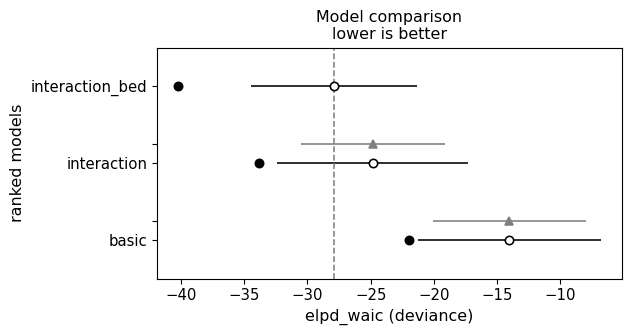

In [11]:
az.plot_compare(comparison, plot_ic_diff=True, insample_dev=True)